<a href="https://colab.research.google.com/github/OmarMohammed88/AR-Emotion-Recognition/blob/main/notebooks/Hubert/Hubert_AR_EmotionRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Amharic Speech Emotion Recognition**

Libraries and resources:
*   Hugging Face Transformers
*   PyTorch
*   Torchaudio
*   Librosa
*   Weights & Biases

The orginal model is found here https://huggingface.co/facebook/wav2vec2-large-960h and our fine-tuned model can be loaded from https://huggingface.co/Gizachew/wev2vec-large960-agu-amharic. I also used the same process to fine-tune the Wev2Vec2.0-base  model and the fine-tuned model can be loaded from this link: https://huggingface.co/Gizachew/wev2vec-base960-agu-amharic

In [ ]:
!nvidia-smi

/opt/conda/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Sun Jun 16 01:50:13 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla P100-PCIE-16GB           Off | 00000000:00:04.0 Off |                    0 |
| N/A   43C    P0              33W / 250W |   1482MiB / 16384MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
%%capture
!pip install datasets transformers torchaudio librosa
!pip install wandb

In [3]:
# File and data handling
import os
import sys
from pathlib import Path

# Progress bar
from tqdm import tqdm

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Audio processing
import librosa
import soundfile as sf
import torchaudio
from torchaudio.transforms import Resample
import IPython.display as ipd

# Machine learning
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Transformers
from transformers import AutoConfig, Wav2Vec2Processor


In [34]:
# Define the path to the dataset
dataset_path = Path('/kaggle/input/asedam-main/ASED_V1-main/')                  

# Retrieve all .wav file paths
audio_file_paths = list(dataset_path.glob(r'**/*.wav'))

# Extract emotion labels from the file paths
emotion_labels = [os.path.basename(os.path.dirname(file_path)) for file_path in audio_file_paths]

# Create a DataFrame with the audio file paths and corresponding emotion labels
data = pd.DataFrame({
    'file_path': [str(file_path) for file_path in audio_file_paths],
    'emotion': emotion_labels
})

# Display the first few rows of the DataFrame
data.head()


,file_path,emotion
0,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
1,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
2,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
3,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
4,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful


In [35]:
audio_data_list = []

# Iterate over each row in the DataFrame
for idx in tqdm(range(len(df_audio))):
    file_path = df_audio['file_path'][idx]
    emotion_label = df_audio['emotion'][idx]
    
    try:
        # Load the audio file using torchaudio
        waveform, sample_rate = torchaudio.load(file_path)
        
        # Append the file path and emotion label to the list
        audio_data_list.append({
            "file_path": file_path,
            "emotion": emotion_label
        })
    except Exception as e:
        continue

# Convert the list to a DataFrame
df_audio_data = pd.DataFrame(audio_data_list)

# Display the first few rows of the DataFrame
df_audio_data.head()


100%|██████████| 2474/2474 [00:27<00:00, 88.80it/s]


,file_path,emotion
0,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
1,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
2,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
3,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
4,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful


In [36]:
# Select a random index
random_index = np.random.randint(0, len(df_audio_data))
sample = df_audio_data.iloc[random_index]

# Extract the file path and emotion label
file_path = sample["file_path"]
emotion_label = sample["emotion"]

print(f"ID Location: {random_index}")
print(f"      Emotion: {emotion_label}")
print()

# Load the audio file
waveform, sample_rate = torchaudio.load(file_path)

# Resample the audio to 16kHz
resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
waveform_resampled = resampler(waveform)
waveform_resampled = waveform_resampled.squeeze().numpy()

# Play the resampled audio
ipd.Audio(data=waveform_resampled, autoplay=True, rate=16000)


ID Location: 85
      Emotion: 02Fearful



For training purposes, we need to split data into train test sets; in this specific example, we break with a `20%` rate for the test set.

## Orginal  Data for Training

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict, load_dataset

# Define the save path
save_path = "/kaggle/working"

# Splitting into training and testing sets (90% training, 10% testing)
train_df, test_df = train_test_split(df_audio_data, test_size=0.1, random_state=42, stratify=df_audio_data["emotion"])

# Splitting training data further into training and validation sets (90% training, 10% validation)
train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42, stratify=train_df["emotion"])

# Resetting indices
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

# Saving to CSV
train_df.to_csv(f"{save_path}/train.csv", sep="\t", index=False)
test_df.to_csv(f"{save_path}/test.csv", sep="\t", index=False)
val_df.to_csv(f"{save_path}/val.csv", sep="\t", index=False)

# Loading datasets using datasets library
data_files = {
    "train": f"{save_path}/train.csv",
    "validation": f"{save_path}/val.csv",
    "test": f"{save_path}/test.csv",
}

dataset = load_dataset("csv", data_files=data_files, delimiter="\t")

# Extracting datasets
train_dataset = dataset["train"]
eval_dataset = dataset["validation"]
test_dataset = dataset["test"]

# Print dataset information
print(train_dataset)
print(eval_dataset)
print(test_dataset)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 2003
})
Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 223
})
Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 248
})


## Data agumentation for training

In [60]:
def add_noise(data):
    noise_value = 0.015 * np.random.uniform() * np.amax(data)
    data = data + noise_value * np.random.normal(size=data.shape[0])
    return data

def stretch_process(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=rate)

def shift_process(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch_process(data, sampling_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=pitch_factor)


In [61]:
# Function to augment and save audio data
def augment_and_save(df_audio_data, split, target_sampling_rate):
    augmented_data_list = []

    for index, row in tqdm(df_audio_data.iterrows(), total=df_audio_data.shape[0]):
        file_path = row['file_path']
        emotion = row['emotion']

        # Load audio file
        speech_array, sampling_rate = torchaudio.load(file_path)

        # Resample and convert to numpy array
        resampler = torchaudio.transforms.Resample(sampling_rate, target_sampling_rate)
        speech = resampler(speech_array).squeeze().numpy()

        # Augment the audio file
        augmented_versions = [
            add_noise(speech),
            stretch_process(speech),
            shift_process(speech),
            pitch_process(speech, target_sampling_rate)
        ]

        for i, augmented_version in enumerate(augmented_versions):
            augmented_file_path = f"{save_path}/{split}_aug_{index}_{i}.wav"
            sf.write(augmented_file_path, augmented_version, target_sampling_rate)

            augmented_data_list.append({
                'file_path': augmented_file_path,
                'emotion': emotion
            })

    augmented_df = pd.DataFrame(augmented_data_list)
    combined_df = pd.concat([df_audio_data, augmented_df]).reset_index(drop=True)
    return combined_df

# Convert Hugging Face datasets to pandas DataFrame for augmentation
train_df = pd.DataFrame(train_dataset)
val_df = pd.DataFrame(eval_dataset)  # Assuming 'eval_dataset' is intended here

# Define target sampling rate
target_sampling_rate = 16000  # Adjust based on your requirements

# Apply augmentation
augmented_train_df = augment_and_save(train_df, "train", target_sampling_rate)
augmented_val_df = augment_and_save(val_df, "val", target_sampling_rate)

# Save the augmented datasets to new CSV files
augmented_train_df.to_csv(f"{save_path}/train_augmented.csv", sep="\t", index=False)
augmented_val_df.to_csv(f"{save_path}/val_augmented.csv", sep="\t", index=False)

100%|██████████| 223/223 [00:16<00:00, 13.79it/s]


In [62]:
from datasets import load_dataset, concatenate_datasets

# Define the paths to the augmented data files
augmented_data_files = {
    "train": f"{save_path}/train_augmented.csv",
    "validation": f"{save_path}/val_augmented.csv",
    "test": f"{save_path}/test.csv",
}

# Load the augmented datasets
augmented_dataset = load_dataset("csv", data_files=augmented_data_files, delimiter="\t")

# Separate the augmented datasets
augmented_train_dataset = augmented_dataset["train"]
augmented_eval_dataset = augmented_dataset["validation"]
test_dataset = dataset["test"]

# Combine the original and augmented train and validation datasets
combined_train_dataset = concatenate_datasets([train_dataset, augmented_train_dataset])
combined_eval_dataset = concatenate_datasets([eval_dataset, augmented_eval_dataset])

# Save the agumented dataset
combined_train_dataset.to_csv(f"{save_path}/combined_train.csv", sep='\t', index=False)
combined_eval_dataset.to_csv(f"{save_path}/combined_val.csv", sep='\t', index=False)

# Print the combined datasets and the original test dataset
print(combined_train_dataset)
print(combined_eval_dataset)
print(test_dataset)


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Creating CSV from Arrow format:   0%|          | 0/13 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 12018
})
Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 1338
})
Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 248
})


## Plot orginal and agumented data

In [63]:
def plot_and_play_waveforms(original_path, augmented_paths, target_sampling_rate):
    original_data = speech_file_to_array_fn(original_path, target_sampling_rate)
    
    plt.figure(figsize=(14, 10))
    plt.subplot(3, 2, 1)
    plt.plot(original_data)
    plt.title('Original')
    display(Audio(original_data, rate=target_sampling_rate))
    
    for i, augmented_path in enumerate(augmented_paths):
        augmented_data = speech_file_to_array_fn(augmented_path, target_sampling_rate)
        plt.subplot(3, 2, i+2)
        plt.plot(augmented_data)
        plt.title(f'Augmented {i+1}')
        display(Audio(augmented_data, rate=target_sampling_rate))
    
    plt.tight_layout()
    plt.show()

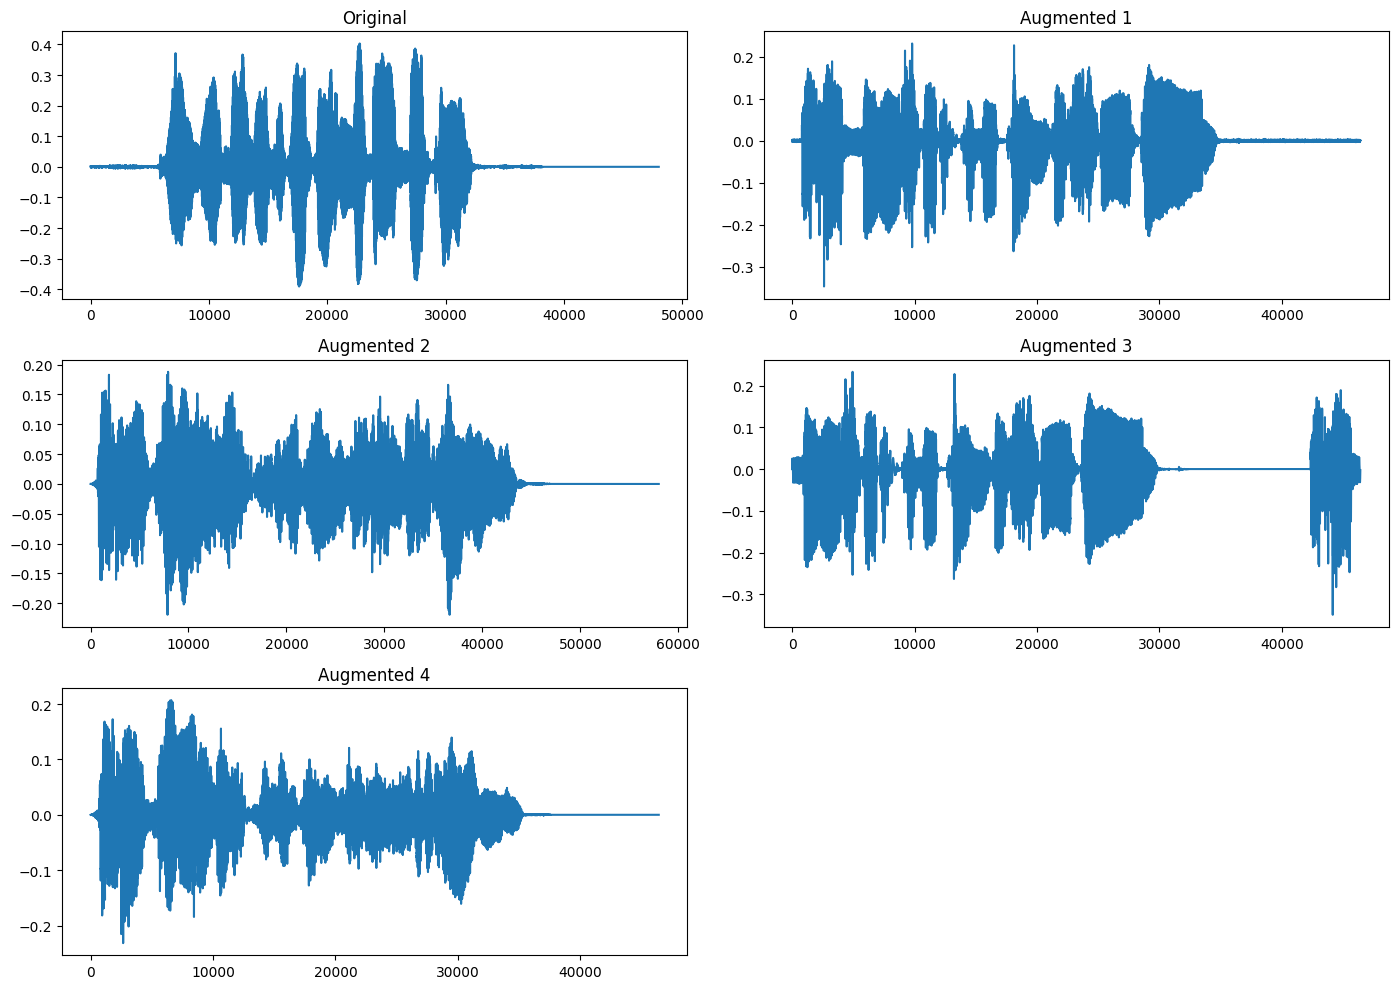

In [66]:
import matplotlib.pyplot as plt
from IPython.display import Audio, display
# Plot original and augmented waveforms for the first entry in the train set
original_path = train_df.iloc[10]['file_path']
augmented_paths = augmented_train_df[augmented_train_df['file_path'].str.contains(f"train_aug_0")]['file_path'].tolist()

plot_and_play_waveforms(original_path, augmented_paths, target_sampling_rate)

In [67]:
# we need to distinguish the unique labels in our SER dataset
input_column = "file_path"
output_column = "emotion"
label_list = combined_train_dataset.unique(output_column)
label_list.sort()  
num_labels = len(label_list)
print(f"A classification problem with {num_labels} classes: {label_list}")

A classification problem with 5 classes: ['01Neutral', '02Fearful', '03Happy', '04Sad', '05Angry']


In [69]:
from transformers import AutoConfig, Wav2Vec2Processor, Wav2Vec2FeatureExtractor
model_name_or_path = "facebook/wav2vec2-large-960h"
pooling_mode = "mean"
config = AutoConfig.from_pretrained(
    model_name_or_path,
    num_labels=num_labels,
    label2id={label: i for i, label in enumerate(label_list)},
    id2label={i: label for i, label in enumerate(label_list)},
    finetuning_task="wev2vec_clf",
)
setattr(config, 'pooling_mode', pooling_mode)

/opt/conda/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

In [70]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name_or_path,)
target_sampling_rate = feature_extractor.sampling_rate
print(f"The target sampling rate: {target_sampling_rate}")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

The target sampling rate: 16000


# Preprocess Data

In [71]:
def speech_file_to_array_fn(path):
    speech_array, sampling_rate = torchaudio.load(path)
    resampler = torchaudio.transforms.Resample(sampling_rate, target_sampling_rate)
    speech = resampler(speech_array).squeeze().numpy()
    return speech

def label_to_id(label, label_list):

    if len(label_list) > 0:
        return label_list.index(label) if label in label_list else -1

    return label

def preprocess_function(examples):
    speech_list = [speech_file_to_array_fn(path) for path in examples[input_column]]
    target_list = [label_to_id(label, label_list) for label in examples[output_column]]

    result = feature_extractor(speech_list, sampling_rate=target_sampling_rate)
    result["labels"] = list(target_list)

    return result

In [72]:
train_dataset = combined_train_dataset.map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)
eval_dataset = combined_eval_dataset.map(
    preprocess_function,
    batch_size=100,
    batched=True,
    num_proc=4
)

Map (num_proc=4):   0%|          | 0/12018 [00:00<?, ? examples/s]

2024-06-27 02:52:15.779725: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 02:52:15.779715: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 02:52:15.779717: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 02:52:15.779722: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 02:52:15.779806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory 

Map (num_proc=4):   0%|          | 0/1338 [00:00<?, ? examples/s]

2024-06-27 02:53:28.714789: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 02:53:28.716638: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-27 02:53:28.718807: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-06-27 02:53:28.730583: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-27 02:53:28.730707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factor

In [73]:
idx = 0
print(f"Training input_values: {train_dataset[idx]['input_values']}")
# print(f"Training attention_mask: {train_dataset[idx]['attention_mask']}")
print(f"Training labels: {train_dataset[idx]['labels']} - {train_dataset[idx]['emotion']}")

Training input_values: [0.0032767837401479483, 0.0021684670355170965, 0.0032767837401479483, 0.0027226253878325224, 0.0027226253878325224, 0.0032767837401479483, 0.0021684670355170965, 0.0032767837401479483, 0.0021684670355170965, 0.0032767837401479483, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0027226253878325224, 0.0032767837401479483, 0.0016143086832016706, 0.003830942092463374, 0.0021684670355170965, 0.0032767837401479483, 0.0021684670355170965, 0.0032767837401479483, 0.0027226253878325224, 0.0021684670355170965, 0.003830942092463374, 0.0010601503308862448, 0.003830942092463374, 0.0016143086832016706, 0.0032767837401479483, 0.0027226253878325224, 0.0027226253878325224, 0.0032767837401479483, 0.0021684670355170965, 0.00383094209

## Wev2Vec2.0 Model

In [74]:
from dataclasses import dataclass
from typing import Optional, Tuple
from torch import Tensor
from transformers.file_utils import ModelOutput

@dataclass
class SpeechClassifierOutput(ModelOutput):
    loss: Optional[Tensor] = None
    logits: Tensor = None
    hidden_states: Optional[Tuple[Tensor]] = None
    attentions: Optional[Tuple[Tensor]] = None

def compute_class_weights(train_set: pd.DataFrame, class_col_name: str) -> Tensor:
    grouped_train_set = train_set.groupby(class_col_name)
    class_counts = torch.tensor([g.shape[0] for _, g in grouped_train_set])
    class_weights = 1 / class_counts.float()
    return class_weights / class_weights.sum()

In [ ]:
# def w_c(train_set: pd.DataFrame, class_col_name) -> torch.Tensor:
#     grouped_train_set = train_set.groupby(class_col_name)
#     numerator = torch.tensor([1 / g.shape[0] for _, g in grouped_train_set])
#     return numerator / numerator.sum()
# weights = w_c(train_df,'emotion')
# print(weights)

tensor([0.1891, 0.1937, 0.2036, 0.2100, 0.2036])


In [75]:
import torch
import torch.nn as nn
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, MSELoss
from transformers.models.wav2vec2.modeling_wav2vec2 import Wav2Vec2PreTrainedModel, Wav2Vec2Model

class Wav2Vec2ClassificationHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.dropout = nn.Dropout(config.final_dropout)
        self.out_proj = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, features):
        x = self.dropout(features)
        x = torch.tanh(self.dense(x))
        x = self.dropout(x)
        x = self.out_proj(x)
        return x

class Wav2Vec2ForSpeechClassification(Wav2Vec2PreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.pooling_mode = config.pooling_mode
        self.config = config

        self.wav2vec2 = Wav2Vec2Model(config)
        self.classifier = Wav2Vec2ClassificationHead(config)

        self.init_weights()

    def freeze_feature_extractor(self):
        self.wav2vec2.feature_extractor._freeze_parameters()

    def forward(
        self,
        input_values,
        attention_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict
        outputs = self.wav2vec2(
            input_values,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        hidden_states = outputs.last_hidden_state

        if self.pooling_mode == "mean":
            pooled_output = torch.mean(hidden_states, dim=1)
        elif self.pooling_mode == "sum":
            pooled_output = torch.sum(hidden_states, dim=1)
        elif self.pooling_mode == "max":
            pooled_output = torch.max(hidden_states, dim=1)[0]
        else:
            raise ValueError(f"Unsupported pooling mode: {self.pooling_mode}")

        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            if self.config.problem_type is None:
                self.config.problem_type = (
                    "regression" if self.num_labels == 1 else "classification"
                )

            if self.config.problem_type == "regression":
                loss_fct = MSELoss()
                loss = loss_fct(logits.view(-1), labels.view(-1).float())
            else:
                if self.num_labels == 1:
                    loss_fct = BCEWithLogitsLoss()
                    loss = loss_fct(logits.view(-1), labels.view(-1).float())
                else:
                    loss_fct = CrossEntropyLoss(weight=self.weights.cuda())
                    loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        if not return_dict:
            return (logits,) + outputs.hidden_states[1:] if loss is None else ((loss,) + (logits,) + outputs.hidden_states[1:])

        return SpeechClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


## Training



In [80]:
from dataclasses import dataclass
from typing import Dict, List, Optional, Union
from transformers import Wav2Vec2FeatureExtractor

@dataclass
class DataCollatorCTCWithPadding:

    feature_extractor: Wav2Vec2FeatureExtractor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [feature["labels"] for feature in features]
        d_type = torch.long if isinstance(label_features[0], int) else torch.float
        batch = self.feature_extractor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        batch["labels"] = torch.tensor(label_features, dtype=d_type)

        return batch

In [81]:
data_collator = DataCollatorCTCWithPadding(feature_extractor=feature_extractor, padding=True)

In [82]:
is_regression = False

In [83]:
import numpy as np
from transformers import EvalPrediction

def compute_metrics(p: EvalPrediction, is_regression: bool):
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    preds = np.squeeze(preds) if is_regression else np.argmax(preds, axis=1)
    if is_regression:
        mse = ((preds - p.label_ids) ** 2).mean().item()
        return {"mse": mse}
    else:
        accuracy = (preds == p.label_ids).astype(np.float32).mean().item()
        return {"accuracy": accuracy}

In [84]:
drive_dir = "/kaggle/working/"
!ls {drive_dir}
output_dir = os.path.join(drive_dir, "wev2vec-large960-agu-amharic")
!mkdir {output_dir}

combined_train.csv    train_aug_1668_3.wav  train_aug_533_2.wav
combined_val.csv      train_aug_1669_0.wav  train_aug_533_3.wav
test.csv	      train_aug_1669_1.wav  train_aug_534_0.wav
train.csv	      train_aug_1669_2.wav  train_aug_534_1.wav
train_aug_0_0.wav     train_aug_1669_3.wav  train_aug_534_2.wav
train_aug_0_1.wav     train_aug_166_0.wav   train_aug_534_3.wav
train_aug_0_2.wav     train_aug_166_1.wav   train_aug_535_0.wav
train_aug_0_3.wav     train_aug_166_2.wav   train_aug_535_1.wav
train_aug_1000_0.wav  train_aug_166_3.wav   train_aug_535_2.wav
train_aug_1000_1.wav  train_aug_1670_0.wav  train_aug_535_3.wav
train_aug_1000_2.wav  train_aug_1670_1.wav  train_aug_536_0.wav
train_aug_1000_3.wav  train_aug_1670_2.wav  train_aug_536_1.wav
train_aug_1001_0.wav  train_aug_1670_3.wav  train_aug_536_2.wav
train_aug_1001_1.wav  train_aug_1671_0.wav  train_aug_536_3.wav
train_aug_1001_2.wav  train_aug_1671_1.wav  train_aug_537_0.wav
train_aug_1001_3.wav  train_aug_1671_2.wav  train_aug

In [85]:
import os
import shutil

last_checkpoint = None
checkpoints = []
if os.path.exists(output_dir):
    for subdir in os.scandir(output_dir):
        if subdir.is_dir():
            checkpoints.append(subdir.path)

if len(checkpoints) > 0:
    checkpoints = list(sorted(checkpoints, key=lambda ckpt: ckpt.split('/')[-1].split('-')[-1], reverse=True))
    model_name_or_path = os.path.join("/content", checkpoints[0].split("/")[-1])
    last_checkpoint = model_name_or_path
    shutil.copytree(checkpoints[0], model_name_or_path)

In [86]:
print(f"model_name_or_path: {model_name_or_path}")
print(f"last_checkpoint: {last_checkpoint}")

model_name_or_path: facebook/wav2vec2-large-960h
last_checkpoint: None


In [87]:
model = Wav2Vec2ForSpeechClassification.from_pretrained(
    model_name_or_path,
    config=config,
)

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of Wav2Vec2ForSpeechClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [88]:
model.freeze_feature_extractor()

In [89]:
model

Wav2Vec2ForSpeechClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=1024, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
 

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    eval_strategy="steps",
    num_train_epochs=5,
    weight_decay=0.01,
    fp16=True,
    save_steps=500,
    eval_steps=500,
    logging_steps=100,
    learning_rate=1e-5,
    save_total_limit=1,
    load_best_model_at_end = True,
    do_train=True,
    do_eval=True,
    do_predict=True
)

Now, all instances can be passed to Trainer and we are ready to start training!

In [ ]:
trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=feature_extractor,
    callbacks=[EarlyStoppingCallback(early_stopping_patience = 3)]
)

### Training

In [ ]:
train_result = trainer.train()
trainer.save_model()
feature_extractor.save_pretrained(training_args.output_dir)
metrics = train_result.metrics
metrics["train_samples"] = len(train_dataset)

trainer.log_metrics("train", metrics)
trainer.save_metrics("train", metrics)
trainer.save_state()

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Step,Training Loss,Validation Loss,Accuracy
500,0.480800,0.461600,0.865471
1000,0.288500,0.409465,0.910314
1500,0.177400,0.328631,0.943199
2000,0.108600,0.442430,0.940209
2500,0.094900,0.413769,0.940209
3000,0.085600,0.415524,0.944694


***** train metrics *****
  epoch                    =       3.9894
  total_flos               = 5808549306GF
  train_loss               =       0.3066
  train_runtime            =   1:30:58.15
  train_samples            =        12018
  train_samples_per_second =       11.009
  train_steps_per_second   =        0.689


In [ ]:
trainer.push_to_hub()

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Upload 4 LFS files:   0%|          | 0/4 [00:00<?, ?it/s]

events.out.tfevents.1718502274.e0d75421cf0a.34.0:   0%|          | 0.00/6.61k [00:00<?, ?B/s]

events.out.tfevents.1718502987.e0d75421cf0a.34.1:   0%|          | 0.00/15.2k [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/5.18k [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Gizachew/wev2vec-large960-agu-amharic/commit/0226396067cac105aa2c94b719c861505989e153', commit_message='End of training', commit_description='', oid='0226396067cac105aa2c94b719c861505989e153', pr_url=None, pr_revision=None, pr_num=None)

In [ ]:
train_logs = trainer.state.log_history

In [ ]:
trainer.evaluate()

{'eval_loss': 0.32863062620162964,
 'eval_accuracy': 0.9431988000869751,
 'eval_runtime': 82.2876,
 'eval_samples_per_second': 16.26,
 'eval_steps_per_second': 2.042,
 'epoch': 3.9893617021276597}

## Evaluation

In [ ]:
import librosa
from datasets import load_dataset, load_metric
from sklearn.metrics import classification_report
from transformers import AutoConfig, Wav2Vec2Processor, Wav2Vec2FeatureExtractor

In [90]:
test_dataset = load_dataset("csv", data_files={"test": "/kaggle/working/test.csv"}, delimiter="\t")["test"]
test_dataset

Generating test split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['file_path', 'emotion'],
    num_rows: 248
})

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
model_name_or_path = "/kaggle/working/wev2vec-large960-agu-amharic/checkpoint-1500"
config = AutoConfig.from_pretrained(model_name_or_path)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name_or_path)
model =  Wav2Vec2ForSpeechClassification.from_pretrained(model_name_or_path).to(device)

In [ ]:
trainer.push_to_hub()

events.out.tfevents.1718508593.e0d75421cf0a.34.2:   0%|          | 0.00/411 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/Gizachew/wev2vec-large960-agu-amharic/commit/d31d8ee848a1aa8cae85a2dbff086fcd31788df8', commit_message='End of training', commit_description='', oid='d31d8ee848a1aa8cae85a2dbff086fcd31788df8', pr_url=None, pr_revision=None, pr_num=None)

In [ ]:
label_names = [config.id2label[i] for i in range(config.num_labels)]
label_names

['01Neutral', '02Fearful', '03Happy', '04Sad', '05Angry']

In [ ]:
def predict(path, sampling_rate):
    speech = speech_file_to_array_fn(path)
    features = feature_extractor(speech, sampling_rate=sampling_rate, return_tensors="pt", padding=True)
    input_values = features.input_values.to(device)
    with torch.no_grad():
        logits = model(input_values).logits
    pred_ids = torch.argmax(logits, dim=-1).detach().cpu().numpy()
    return pred_ids

In [ ]:
test_df['predicted'] = 0
for i in range(len(test_df)):
  test_df.loc[i,'predicted'] = predict(test_df['file_path'][i],16000)

In [ ]:
y_true = test_df['emotion'].to_list()
y_pred = test_df['predicted'].to_list()

In [ ]:
y_df = pd.DataFrame({"pred":y_pred})
y_df.pred = y_df.pred.map({0: '01Neutral',1: '02Fearful', 2: '03Happy', 3: '04Sad', 4: '05Angry'}.get)
y_pred = y_df.pred.tolist()

In [ ]:
print(classification_report(y_true, y_df['pred'].tolist(), target_names=label_names))


              precision    recall  f1-score   support

   01Neutral       0.98      0.96      0.97        52
   02Fearful       0.92      0.90      0.91        51
     03Happy       0.94      1.00      0.97        49
       04Sad       1.00      0.96      0.98        47
     05Angry       0.98      1.00      0.99        49

    accuracy                           0.96       248
   macro avg       0.96      0.96      0.96       248
weighted avg       0.96      0.96      0.96       248



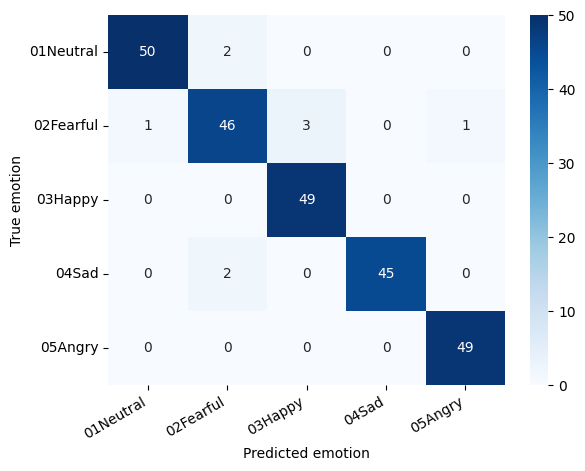

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True emotion')
  plt.xlabel('Predicted emotion');
  plt.savefig("hu_largeagu_confusion.png")
cm = confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=label_names, columns=label_names)
show_confusion_matrix(df_cm)

# Prediction

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name_or_path = "/kaggle/working/wev2vec-large960-agu-amharic/checkpoint-1500"
config = AutoConfig.from_pretrained(model_name_or_path)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(model_name_or_path)
sampling_rate = feature_extractor.sampling_rate
model =  Wav2Vec2ForSpeechClassification.from_pretrained(model_name_or_path).to(device)

In [ ]:
def speech_file_to_array_fn(path, sampling_rate):
    speech_array, _sampling_rate = torchaudio.load(path)
    resampler = torchaudio.transforms.Resample(_sampling_rate)
    speech = resampler(speech_array).squeeze().numpy()
    return speech


def predict(path, sampling_rate):
    speech = speech_file_to_array_fn(path, sampling_rate)
    features = feature_extractor(speech, sampling_rate=sampling_rate, return_tensors="pt", padding=True)

    input_values = features.input_values.to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    scores = F.softmax(logits, dim=1).detach().cpu().numpy()[0]
    outputs = [{"Label": config.id2label[i], "Score": f"{round(score * 100, 3):.1f}%"} for i, score in enumerate(scores)]
    return outputs


STYLES = """
<style>
div.display_data {
    margin: 0 auto;
    max-width: 500px;
}
table.xxx {
    margin: 50px !important;
    float: right !important;
    clear: both !important;
}
table.xxx td {
    min-width: 300px !important;
    text-align: center !important;
}
</style>
""".strip()

def prediction(df_row):
    path, label = df_row["file_path"], df_row["emotion"]
    df = pd.DataFrame([{"Emotion": label, "Sentence": "    "}])
    setup = {
        'border': 2,
        'show_dimensions': True,
        'justify': 'center',
        'classes': 'xxx',
        'escape': False,
    }
    ipd.display(ipd.HTML(STYLES + df.to_html(**setup) + "<br />"))
    speech, sr = torchaudio.load(path)
    resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
    speech_resampled = resampler(speech)
    speech_resampled = speech_resampled.squeeze().numpy()
    ipd.display(ipd.Audio(data=np.asarray(speech), autoplay=True, rate=sampling_rate))

    outputs = predict(path, sampling_rate)
    r = pd.DataFrame(outputs)
    ipd.display(ipd.HTML(STYLES + r.to_html(**setup) + "<br />"))

In [91]:
test = pd.read_csv("/kaggle/working/test.csv", sep="\t")
test.head()

,file_path,emotion
0,/kaggle/input/asedam-main/ASED_V1-main/04Sad/s...,04Sad
1,/kaggle/input/asedam-main/ASED_V1-main/05Angry...,05Angry
2,/kaggle/input/asedam-main/ASED_V1-main/02Fearf...,02Fearful
3,/kaggle/input/asedam-main/ASED_V1-main/01Neutr...,01Neutral
4,/kaggle/input/asedam-main/ASED_V1-main/04Sad/s...,04Sad


In [ ]:
prediction(test.iloc[1])

,Emotion,Sentence
0,05Angry,


,Label,Score
0,01Neutral,0.0%
1,02Fearful,0.0%
2,03Happy,0.0%
3,04Sad,0.0%
4,05Angry,99.9%


In [ ]:
prediction(test.iloc[10])

,Emotion,Sentence
0,03Happy,


,Label,Score
0,01Neutral,0.0%
1,02Fearful,0.0%
2,03Happy,99.7%
3,04Sad,0.1%
4,05Angry,0.1%


In [ ]:
prediction(test.iloc[11])

,Emotion,Sentence
0,04Sad,


,Label,Score
0,01Neutral,0.0%
1,02Fearful,0.0%
2,03Happy,0.0%
3,04Sad,99.9%
4,05Angry,0.0%
